In [2]:
%load_ext autoreload
%autoreload 2
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from spts.scripts import cxd_to_h5





/home/pat/spts-testing/spts/spts/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [19]:
    #_, _, _, _ = cxd_to_h5.estimate_background('/home/pat/spts-testing/spts-data/data00657.cxd', i, read_cache=False)
    
    
    #plt.xlim([-25,25])

*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.
Calculating background estimate by mean of buffer...done.
Found 178865 bad pixels and 4015439 good pixels.
Mean over mean background = 99
Std dev over mean background = 21
Writing out h5...done.
[ 0.12141643 -0.27947803  3.1473748 ]


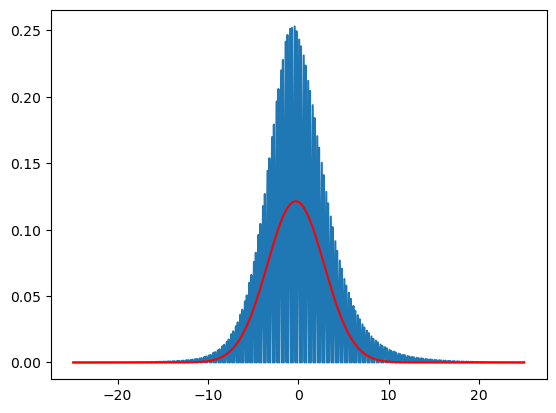

In [20]:
_, _, _, _, bins, hist = cxd_to_h5.estimate_background('/home/pat/spts-testing/spts-data/data00657.cxd', 10, read_cache=False)

bin_mids = bins[:-1]+np.diff(bins)
def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
popt, pcov = scipy.optimize.curve_fit(gauss, bin_mids, hist, bounds = ([0,-10,0], [1,10,20]))
print(popt)

plt.plot(bin_mids, hist)
plt.plot(bin_mids, gauss(bin_mids, popt[0], popt[1], popt[2]), 'r')



In [3]:
_, _, _, _, bins, hist, mu_mle, sigma_mle = cxd_to_h5.estimate_background('/home/pat/spts-testing/spts-data/data00657.cxd', 10, read_cache=False, hist_bins=100)

*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.
Calculating background estimate by mean of buffer...done.
Found 178865 bad pixels and 4015439 good pixels.
Mean over mean background = 99
Std dev over mean background = 21
Writing out h5...done.


[-0.28237543  3.25223477]


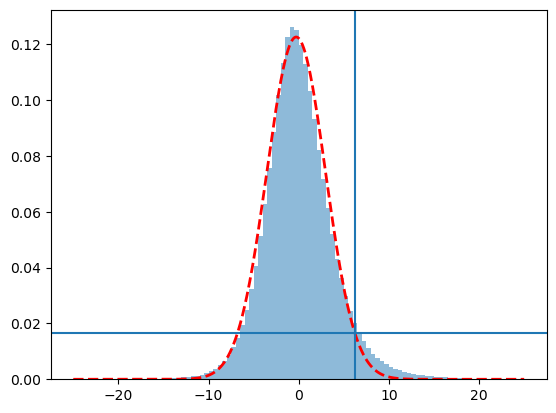

In [17]:
bin_mids = (bins[:-1] + bins[1:]) / 2.0

def gpdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
    
popt, pcov = scipy.optimize.curve_fit(gpdf, bin_mids, hist)
print(popt)
xplot = np.linspace(bins[0], bins[-1], 1000)
plt.figure()
plt.bar(bin_mids, hist, width=np.diff(bins), align='center', alpha=0.5, label='Histogram (density)')
plt.plot(xplot, gpdf(xplot, *popt), 'r', lw=2,linestyle='dashed', label='Gaussian PDF fit')
plt.axhline((1.0 / (popt[1] * np.sqrt(2*np.pi)))/(np.e**2))
plt.axvline(popt[0]+2*popt[1])

[ 0.42195062 -0.30679597  4.85060952  2.55626896]


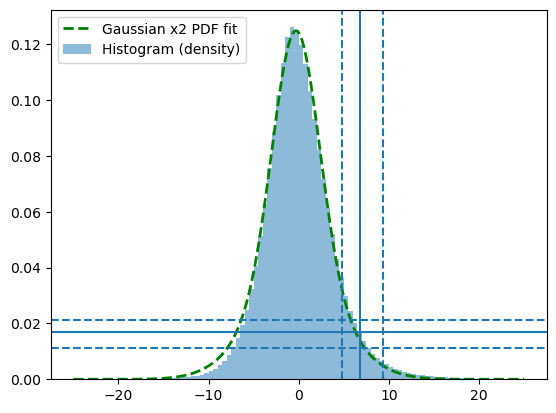

In [22]:
def mix2_gpdf(x, w, mu, sigma1, sigma2):
    g1 = (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma1**2))
    g2 = (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma2**2))
    return w * g1 + (1 - w) * g2

popt, pcov = scipy.optimize.curve_fit(mix2_gpdf, bin_mids, hist)
print(popt)
xplot = np.linspace(bins[0], bins[-1], 1000)
plt.figure()
plt.bar(bin_mids, hist, width=np.diff(bins), align='center', alpha=0.5, label='Histogram (density)')
plt.plot(xplot, mix2_gpdf(xplot, *popt), 'g', lw=2,linestyle='dashed', label='Gaussian x2 PDF fit')


plt.axhline((1.0 / (popt[2] * np.sqrt(2*np.pi)))/(np.e**2), linestyle='dashed')
plt.axhline((1.0 / (popt[3] * np.sqrt(2*np.pi)))/(np.e**2), linestyle='dashed')
plt.axhline( popt[0]*(1.0 / (popt[2] * np.sqrt(2*np.pi)))/(np.e**2) + (1-popt[0])*(1.0 / (popt[3] * np.sqrt(2*np.pi)))/(np.e**2))

plt.axvline(popt[1]+2*popt[2], linestyle='dashed')
plt.axvline(popt[1]+2*popt[3], linestyle='dashed')
plt.axvline( popt[0]*(popt[1]+2*popt[2]) + (1-popt[0])*(popt[1]+2*popt[3]))

plt.legend()
plt.show()